In [1]:
# ====================================================
# Libraries
# ====================================================

import numpy as np
import pandas as pd
from scipy.integrate import trapezoid, cumulative_trapezoid
import emcee
import time
from getdist import MCSamples, plots
import matplotlib.pyplot as plt
from scipy.stats import chi2 as chi2_dist

In [2]:
# =========================
# Loading CC data
# =========================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err  = df_cc["H_cc_err"].to_numpy(float)


# ========================================================
# Loading SNe Ia data
# ========================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask = df_sne["zCMB"].values > 0.01
df_cut = df_sne[mask].reset_index(drop=True)
Cov_sne = Cov_sne_full[mask, :][:, mask]
z_sne = df_cut["zCMB"].values
mB_obs = df_cut["m_b_corr"].values
Cinv_sne = np.linalg.inv(Cov_sne)

# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"
df_bao = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values
cov_bao = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_MW_total  = DM_MW + 50.0          # MW ISM + halo contribution [pc/cm^3]
DM_ext_obs   = DM_obs - DM_MW_total  # extragalactic DM [pc/cm^3]

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,  90.0
Om0_min,      Om0_max      = 0.1,   0.6
Ob_min,       Ob_max       = 0.01,  0.1
MB_min,       MB_max       = -20.0, -18.0
w0_min,       w0_max       = -3.0,   1.0
wa_min,       wa_max       = -3.0,   2.0
sig_host_min, sig_host_max = 0.2,    2.0
e_mu_min,     e_mu_max     = 20.0,   200.0

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc  = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical/cosmological parameters
f_IGM = 0.83
chi_e = 0.875
Neff  = 3.046

# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ==============================
# Hubble functions
# ==============================

def E_CPL(z, Om0, w0, wa):
    Om = Om0 * (1 + z)**3

    Ode0 = 1 - Om0
    power = 3*(1 + w0 + wa)
    fde = np.exp(-3*wa*z/(1+z))
    Ode = Ode0 * (1 + z)**power * fde
    return np.sqrt(Om + Ode)

def H_CPL(z, H0, Om0, w0, wa):
    return H0 * E_CPL(z, Om0, w0, wa)


# ========================================================
# Luminosity distance
# ========================================================

def dL_CPL(z, H0, Om0, w0, wa):
    prefactor  = c_kms * (1.0 + z)
    H_grid     = H_CPL(z_grid, H0, Om0, w0, wa)
    integrand  = 1.0 / H_grid
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z


# ========================================================
# Comoving distance
# ========================================================

def comoving_dist(z, H0, Om0, w0, wa):
    E_vals = E_CPL(z_grid, Om0, w0, wa)
    integrand = 1.0 / E_vals
    integral = np.empty_like(z_grid)
    integral[0] = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return (c_kms / H0) * I_z

In [5]:
# ========================================================
# Apparent magnitude
# ========================================================

def mB_CPL(z, H0, Om0, MB, w0, wa):
    dL = dL_CPL(z, H0, Om0, w0, wa)
    mu = 5.0 * np.log10(dL) + 25.0 
    return mu + MB


# ====================================================
# Theoretical BAO vector
# ====================================================

def d_CPL(z_arr, q_arr, H0, Om0, Ob, w0, wa):
    h2 = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd = 147.05 * ((Obh2/0.02236)**-0.13) \
                  * ((Omh2/0.1432)**-0.23) \
                  * ((Neff/3.04)**-0.1)
    dC = comoving_dist(z_arr, H0, Om0, w0, wa)
    H_z = H_CPL(z_arr, H0, Om0, w0, wa)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1/3)
    d_bao = np.empty_like(z_arr)
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao


# ====================================================
# Theoretical IGM dispersion measure [pc/cm^3]
# ====================================================

def DM_IGM_CPL(z, H0, Om0, Ob, w0, wa):
    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_grid    = H_CPL(z_grid, H0, Om0, w0, wa)
    integrand = (1 + z_grid) / H_grid
    I_grid    = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, I_grid)
    DM_IGM_z    = prefactor * Ob * H0**2 * I_z                      # Before units conversion
    DM_IGM_corr = DM_IGM_z * (km_to_pc / (m2_to_cm2 * Mpc_to_cm))   # Physical units (pc cm^-3)
    return DM_IGM_corr

In [6]:
# ====================================================
# CC + SNe + BAO + FRB Likelihood
# ====================================================

# Log-priors
def lnprior_cc_sne_bao_frb(theta):
    H0, Om0, Ob, MB, w0, wa, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):        return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):       return -np.inf
    if not (Ob_min       <= Ob         <= Ob_max):        return -np.inf
    if not (MB_min       <= MB         <= MB_max):        return -np.inf
    if not (w0_min       <= w0         <= w0_max):        return -np.inf
    if not (wa_min       <= wa         <= wa_max):        return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max):  return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):      return -np.inf
    return 0.0


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM, sigma_host, exp_mu, npts=300):
    mu_host = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)              
    DM_hosp_grid = DM_hosp_grid[None, :]                      
    DM_ext_array = DM_ext_obs[:, None]                    
    DM_IGM_array = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None]) 
    sigma_IGM_array = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    P_IGM = (1.0 / (np.sqrt(2*np.pi) * sigma_IGM_array)) \
            * np.exp(-0.5 * ((DM_IGM_array - DM_IGM_mean_array)/sigma_IGM_array)**2)

    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2*np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host)/sigma_host)**2)

    integrand = P_IGM * P_host 
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Log-likelihood
def lnlike_cc_sne_bao_frb(theta,
                          z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs, npts=300):
    H0, Om0, Ob, MB, w0, wa, sigma_host, exp_mu = theta
    # -------------------------------------------------
    # CC part
    # -------------------------------------------------
    H_model = H_CPL(z_cc, H0, Om0, w0, wa)
    chi2_cc = np.sum(((H_obs - H_model) / H_err)**2) 
    lnL_cc  = -0.5 * chi2_cc
    # -------------------------------------------------
    # SNe part
    # -------------------------------------------------
    mB_model  = mB_CPL(z_sne, H0, Om0, MB, w0, wa)
    resid_sne = mB_obs - mB_model
    chi2_sne  = resid_sne @ Cinv_sne @ resid_sne
    lnL_sne   = -0.5 * chi2_sne
    # -------------------------------------------------
    # BAO part
    # -------------------------------------------------
    d_model   = d_CPL(z_bao, q_bao, H0, Om0, Ob, w0, wa)
    resid_bao = d_obs - d_model
    chi2_bao  = resid_bao @ Cinv_bao @ resid_bao
    lnL_bao   =  -0.5 * chi2_bao
    # -------------------------------------------------
    # FRB part
    # -------------------------------------------------
    DM_IGM_mean = DM_IGM_CPL(z_frb, H0, Om0, Ob, w0, wa)
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                  sigma_IGM, sigma_host, exp_mu, npts=npts)
    lnL_frb = np.sum(np.log(P_total))
    return lnL_cc + lnL_sne + lnL_bao + lnL_frb


# Log-posterior
def lnprob_cc_sne_bao_frb(theta,
                          z_cc, H_obs, H_err,
                          z_sne, mB_obs, Cinv_sne,
                          z_bao, d_obs, q_bao, Cinv_bao,
                          z_frb, DM_ext_obs):
    lp = lnprior_cc_sne_bao_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = lnlike_cc_sne_bao_frb(theta,
                           z_cc, H_obs, H_err,
                           z_sne, mB_obs, Cinv_sne,
                           z_bao, d_obs, q_bao, Cinv_bao,
                           z_frb, DM_ext_obs, npts=300)
    return lp + ll


# ====================================================
# Quick test
# ====================================================

theta_test = [70, 0.3, 0.0495, -19.24, -1.0, 0.0, 0.7, 120]
print("CC + SNe + BAO + FRB log-posterior =",
       lnprob_cc_sne_bao_frb(theta_test, 
                             z_cc, H_obs, H_err,
                             z_sne, mB_obs, Cinv_sne,
                             z_bao, d_obs, q_bao, Cinv_bao,
                             z_frb, DM_ext_obs))

CC + SNe + BAO + FRB log-posterior = -1837.256541961458


In [7]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 8
nwalkers = 64
nsteps   = 50000

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, -1.0, 0.0, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02,  0.1, 0.2, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + SNe + BAO + FRB) ===")
t_mcmc = time.time()

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob_cc_sne_bao_frb,
    args=(z_cc, H_obs, H_err,
          z_sne, mB_obs, Cinv_sne,
          z_bao, d_obs, q_bao, Cinv_bao,
          z_frb, DM_ext_obs),
)
sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + SNe + BAO + FRB) ===


100%|██████████| 50000/50000 [46:46<00:00, 17.82it/s]


MCMC completed in 46.8 min


In [8]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.451
Acceptance status: IDEAL

Max autocorrelation time τ_max = 109.74
Chain length / τ_max           = 455.6
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 329 steps (0.7%)
Thin (τ_max/2)                 = 54
Minimum N_eff                  = 28967
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [9]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log    = sampler.get_chain(discard=nburn, thin=nthin, flat=True)       # Apply thin
flat_log      = sampler.get_chain(discard=nburn, flat=True)                   # No thin
flat_samples  = flat_log.copy()

# Save flat samples
fname = "flat_samples_CPL_cc_sne_bao_frb.npy"
np.save(fname, flat_samples)

# Save log-posterior (enables MAP in future sessions)
fname_lp = "log_prob_CPL_cc_sne_bao_frb.npy"
log_prob_flat = sampler.get_log_prob(discard=nburn, flat=True)
np.save(fname_lp, log_prob_flat)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used                : {nburn} steps")
print(f"Saved to                    : {fname}")
print(f"Log-posterior saved to      : {fname_lp}")


Final independent samples : 3178944
Burn-in used                : 329 steps
Saved to                    : flat_samples_CPL_cc_sne_bao_frb.npy
Log-posterior saved to      : log_prob_CPL_cc_sne_bao_frb.npy


Removed no burn in


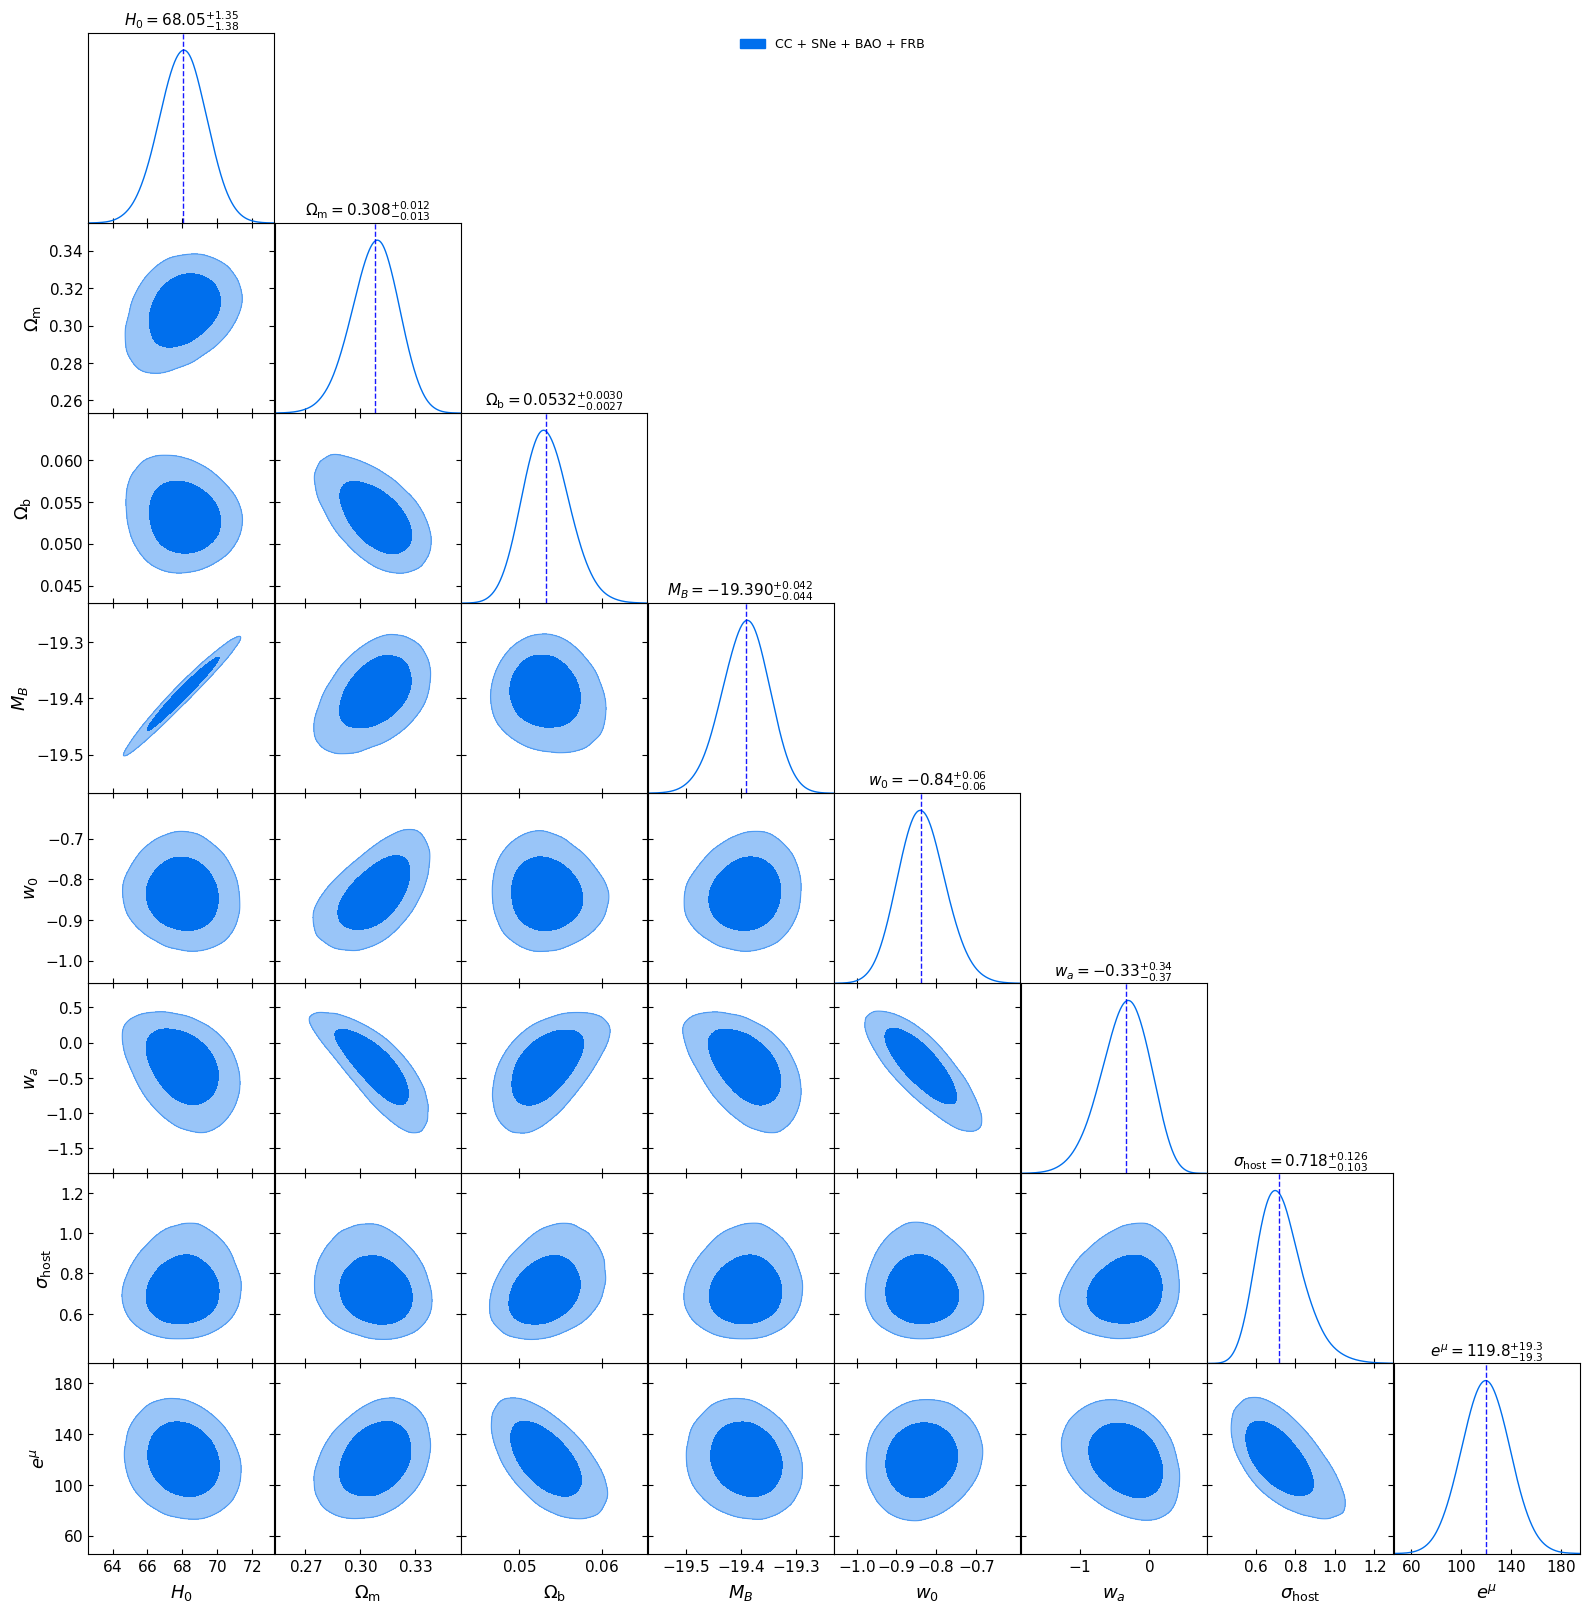

In [10]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "w0", "wa", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}",
                r"M_B", r"w_0", r"w_a", r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + SNe + BAO + FRB"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "w0": ".2f", "wa": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68

    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = "Corner_CPL_cc_sne_bao_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("MB", 3), ("w0", 4), ("wa", 5), ("sigma_host", 6), ("exp_mu", 7)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "w0": ".2f", "wa": ".2f", "sigma_host": ".3f", "exp_mu": ".1f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (CPL model | CC + SNe + BAO + FRB data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")

print("\n" + "="*60)


Final Inference Results (CPL model | CC + SNe + BAO + FRB data)

  H0:
    68.05 +1.35 -1.38  (68% CL)
    68.05 +2.64 -2.75  (95% CL)

  Om0:
    0.308 +0.012 -0.013  (68% CL)
    0.308 +0.024 -0.027  (95% CL)

  Ob:
    0.0532 +0.0030 -0.0027  (68% CL)
    0.0532 +0.0061 -0.0052  (95% CL)

  MB:
    -19.390 +0.042 -0.044  (68% CL)
    -19.390 +0.081 -0.089  (95% CL)

  w0:
    -0.84 +0.06 -0.06  (68% CL)
    -0.84 +0.12 -0.11  (95% CL)

  wa:
    -0.33 +0.34 -0.37  (68% CL)
    -0.33 +0.62 -0.76  (95% CL)

  sigma_host:
    0.718 +0.126 -0.103  (68% CL)
    0.718 +0.277 -0.189  (95% CL)

  exp_mu:
    119.8 +19.3 -19.3  (68% CL)
    119.8 +38.2 -37.8  (95% CL)



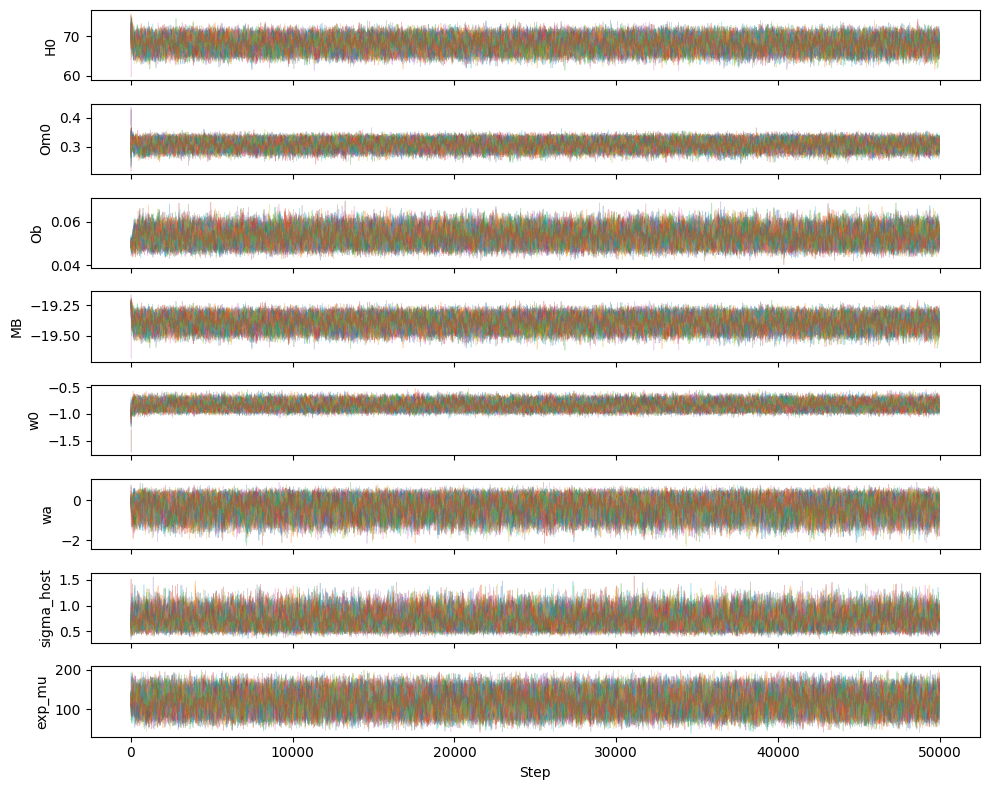

In [12]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(8, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "w0", "wa", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [13]:
# ========================================================
# Derived Parameter: Sound Horizon rd
# ========================================================

def compute_rd(H0, Om0, Ob):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    return rd

# Compute rd for entire posterior
# flat_samples columns: [H0, Om0, Ob, MB, "w0", "wa", sigma_host, exp_mu]
rd_chain = np.array([
    compute_rd(s[0], s[1], s[2]) for s in flat_samples
])

mean_rd  = np.mean(rd_chain)
std_rd   = np.std(rd_chain)
lower_95 = np.percentile(rd_chain, 2.5)
upper_95 = np.percentile(rd_chain, 97.5)

print("\n" + "="*60)
print(f"{'DERIVED SOUND HORIZON':^60}")
print("="*60)
print(f"  r_d = {mean_rd:.3f} ± {std_rd:.3f} Mpc (68% CL)")
print(f"  95% CL : [{lower_95:.3f}, {upper_95:.3f}] Mpc")
print("="*60)


                   DERIVED SOUND HORIZON                    
  r_d = 145.437 ± 2.705 Mpc (68% CL)
  95% CL : [140.406, 151.020] Mpc


In [14]:
# ====================================================
# Model selection statistics
# ====================================================

# Toggle: load samples from file or use sampler from memory
LOAD_FROM_FILE = False   # True = load from .npy | False = use sampler in memory

if LOAD_FROM_FILE:
    fname        = "flat_samples_CPL_cc_sne_bao_frb.npy"
    fname_lp     = "log_prob_CPL_cc_sne_bao_frb.npy"
    flat_samples  = np.load(fname)
    log_prob_flat = np.load(fname_lp)
    idx_map  = np.argmax(log_prob_flat)
    theta_bf = flat_samples[idx_map]
    print(f"Loaded {len(flat_samples)} samples from {fname}")
    print(f"Best-fit (MAP): {theta_bf}")

else:
    idx_map  = np.argmax(sampler.get_log_prob(discard=nburn, flat=True))
    theta_bf = flat_samples[idx_map]
    print(f"Best-fit (MAP): {theta_bf}")

theta_bf_like = theta_bf.copy()

# Maximum log-likelihood
lnL_max = lnlike_cc_sne_bao_frb(
    theta_bf_like,
    z_cc, H_obs, H_err,
    z_sne, mB_obs, Cinv_sne,
    z_bao, d_obs, q_bao, Cinv_bao,
    z_frb, DM_ext_obs
)

# Number of data points
N_cc  = len(z_cc)
N_sne = len(z_sne)
N_bao = len(z_bao)
N_frb = len(z_frb)
N_tot = N_cc + N_sne + N_bao + N_frb

# Number of free parameters
k = flat_samples.shape[1]

# Chi-squared
chi2     = -2.0 * lnL_max
dof      = N_tot - k
chi2_red = chi2 / dof

# AIC and BIC
AIC = 2.0 * k - 2.0 * lnL_max
BIC = k * np.log(N_tot) - 2.0 * lnL_max

print("\n" + "="*60)
print(f"{'MODEL SELECTION STATISTICS':^60}")
print(f"{'(CPL: CC + SNe + BAO + FRB)':^60}")
print("="*60)
print(f"\n  Data points:")
print(f"    CC       : {N_cc}")
print(f"    SNe      : {N_sne}")
print(f"    BAO      : {N_bao}")
print(f"    FRB      : {N_frb}")
print(f"    Total    : {N_tot}")
print(f"\n  Free parameters (k) : {k}")
print(f"  Degrees of freedom  : {dof}")
print(f"\n  ln L_max  = {lnL_max:.4f}")
print(f"  χ²        = {chi2:.4f}")
print(f"  χ²/dof    = {chi2_red:.4f}")
print(f"  AIC       = {AIC:.4f}")
print(f"  BIC       = {BIC:.4f}")
print("\n" + "="*60)

Best-fit (MAP): [ 6.82214808e+01  3.07118513e-01  5.36591751e-02 -1.93846868e+01
 -8.34114859e-01 -3.31728440e-01  6.85717477e-01  1.17531236e+02]

                 MODEL SELECTION STATISTICS                 
                (CPL: CC + SNe + BAO + FRB)                 

  Data points:
    CC       : 35
    SNe      : 1588
    BAO      : 13
    FRB      : 104
    Total    : 1740

  Free parameters (k) : 8
  Degrees of freedom  : 1732

  ln L_max  = -1378.1263
  χ²        = 2756.2526
  χ²/dof    = 1.5914
  AIC       = 2772.2526
  BIC       = 2815.9458



In [15]:
# # ====================================================
# # Model comparison: CPL vs LCDM
# # ====================================================

# # ---- Stored results ----
# lnL_LCDM = -1384.1466;    k_LCDM = 6
# lnL_CPL  = lnL_max;        k_CPL = k
# AIC_LCDM = 2780.2932;   BIC_LCDM = 2813.0631
# AIC_CPL  = AIC;          BIC_CPL = BIC
# # N_tot    = 1740

# # ---- Differences (alternative - reference = CPL - LCDM) ----
# delta_lnL  = lnL_CPL - lnL_LCDM    # positive = CPL fits better
# delta_chi2 = -2.0 * delta_lnL      # negative = CPL has lower chi2
# delta_AIC  = AIC_CPL - AIC_LCDM    # negative = CPL preferred by AIC
# delta_BIC  = BIC_CPL - BIC_LCDM    # negative = CPL preferred by BIC
# delta_k    = k_CPL - k_LCDM        # number of extra parameters

# # ---- Likelihood ratio test ----
# # LRT statistic is always positive: -2*(lnL_restricted - lnL_full)
# # = -2*(lnL_LCDM - lnL_CPL) = 2*delta_lnL
# LRT_stat = 2.0 * delta_lnL
# p_value  = chi2_dist.sf(LRT_stat, df=delta_k)

# # ---- AIC interpretation (Burnham & Anderson 2002) ----
# # Based on delta_AIC = AIC_candidate - AIC_best
# # Negative delta_AIC means candidate (CPL) is preferred
# def interpret_AIC(delta):
#     """
#     delta = AIC_alternative - AIC_reference
#     Negative: alternative preferred; Positive: reference preferred.
#     Burnham & Anderson (2002) scale.
#     """
#     if   delta < -10: return "Very strong support for alternative"
#     elif delta <  -4: return "Considerable support for alternative"
#     elif delta <  -2: return "Positive support for alternative"
#     elif delta <=  2: return "Substantial support for both models"
#     elif delta <=  4: return "Positive support for reference"
#     elif delta <= 10: return "Considerable support for reference"
#     else:             return "Very strong support for reference"

# # ---- BIC / Jeffreys scale (Kass & Raftery 1995) ----
# # 2*ln(BF) ≈ -delta_BIC; negative delta_BIC = evidence for alternative
# def interpret_BIC(delta):
#     """
#     delta = BIC_alternative - BIC_reference
#     Negative: evidence for alternative; Positive: evidence for reference.
#     Kass & Raftery (1995) scale applied to -delta_BIC = 2*ln(BF).
#     """
#     lnBF = -0.5 * delta   # approximate log Bayes factor
#     if   lnBF >  5:  return f"Very strong evidence for alternative   (ln BF ≈ {lnBF:+.2f})"
#     elif lnBF >  3:  return f"Strong evidence for alternative        (ln BF ≈ {lnBF:+.2f})"
#     elif lnBF >  1:  return f"Positive evidence for alternative      (ln BF ≈ {lnBF:+.2f})"
#     elif lnBF > -1:  return f"Not significant                        (ln BF ≈ {lnBF:+.2f})"
#     elif lnBF > -3:  return f"Positive evidence against alternative  (ln BF ≈ {lnBF:+.2f})"
#     elif lnBF > -5:  return f"Strong evidence against alternative    (ln BF ≈ {lnBF:+.2f})"
#     else:            return f"Very strong evidence against alt.      (ln BF ≈ {lnBF:+.2f})"

# # ---- LRT interpretation ----
# def interpret_LRT(p):
#     if   p < 0.001: return "Extra parameter highly significant (p < 0.001)"
#     elif p < 0.01:  return "Extra parameter significant        (p < 0.01)"
#     elif p < 0.05:  return "Extra parameter significant        (p < 0.05)"
#     else:           return "Extra parameter NOT significant    (p ≥ 0.05)"

# # ---- Print ----
# print("\n" + "="*65)
# print(f"{'MODEL COMPARISON: CPL vs LCDM':^65}")
# print(f"{'(CC + SNe + BAO + FRB)':^65}")
# print("="*65)

# print(f"\n  {'Quantity':<32} {'LCDM':>10} {'CPL':>10}")
# print(f"  {'-'*55}")
# print(f"  {'k (free parameters)':<32} {k_LCDM:>10} {k_CPL:>10}")
# print(f"  {'ln L_max':<32} {lnL_LCDM:>10.4f} {lnL_CPL:>10.4f}")
# print(f"  {'χ²  = -2 ln L_max':<32} {-2*lnL_LCDM:>10.4f} {-2*lnL_CPL:>10.4f}")
# print(f"  {'χ²/dof':<32} {(-2*lnL_LCDM)/(N_tot-k_LCDM):>10.4f} {(-2*lnL_CPL)/(N_tot-k_CPL):>10.4f}")
# print(f"  {'AIC = 2k - 2 ln L':<32} {AIC_LCDM:>10.4f} {AIC_CPL:>10.4f}")
# print(f"  {'BIC = k ln N - 2 ln L':<32} {BIC_LCDM:>10.4f} {BIC_CPL:>10.4f}")

# print(f"\n  {'Differences  Δ = CPL - LCDM'}")
# print(f"  {'-'*55}")
# print(f"  {'Δ ln L':<32} {delta_lnL:>+10.4f}")
# print(f"  {'Δχ²  = -2 Δ ln L':<32} {delta_chi2:>+10.4f}")
# print(f"  {'Δk':<32} {delta_k:>+10}")
# print(f"  {'ΔAIC':<32} {delta_AIC:>+10.4f}")
# print(f"  {'ΔBIC':<32} {delta_BIC:>+10.4f}")

# print(f"\n  {'AIC verdict':}")
# print(f"  → {interpret_AIC(delta_AIC)}")

# print(f"\n  {'BIC verdict (Kass & Raftery 1995)':}")
# print(f"  → {interpret_BIC(delta_BIC)}")

# print(f"\n  {'Likelihood Ratio Test  (H0: LCDM,  H1: CPL)'}")
# print(f"  {'-'*55}")
# print(f"  {'LRT statistic':<32} {LRT_stat:>10.4f}")
# print(f"  {'Δk (extra parameters)':<32} {delta_k:>10}")
# print(f"  {'p-value':<32} {p_value:>10.4f}")
# print(f"  → {interpret_LRT(p_value)}")

# print("\n" + "="*65)